# Práctica 6 : Detección y comparación de huellas dactilares
## Miembros del equipo:
- Luna Yue Hernández Guerra
- Jorge Lorenzo Lorenzo
---
## Hipotésis Base
La hipótesis base se encuentra explicada en el archivo `Hipotesis_IA.md`.

## Desarrollo
### Preprocesamiento de imágenes
Se va a realizar el mismo preprocesamiento que en la de sin IA, así que no se vuelve a aplicar el preprocemiento aquí.

### Red neuronal para extracción de características
Para la realización de la extracción de caracteristicas se ha utilizado una red neuronal convolucional llamada `Siamesa` que estaba propuesta como ejemplo en el enunciado de la práctica. Las bloques de dicha red son los siguientes:

- **Bloque convolucional**: Es la parte encargada de extraer los patrones visuales de las imagenes, donde se utliza Relu como función de activación y MaxPooling para reducir la dimensionalidad de las características extraídas.

- **Bloque de Fully Connected**: Es la parte encargada de transformar las características extraídas por el bloque convolucional en un vector de características.

Luego se aplica una normalización usando la función `F.normalize` para que los vectores tengan una norma igual a 1, lo que facilita la comparación entre ellos.

#### Código de la red neuronal

In [2]:
import os
import torch
from utils_ia import (
    SiameseCNN,
    entrenar_siamese,
    comparar_huellas_ia,
    dibujar_curvas_error_ia,
    procesar_y_comparar_test_ia
)

OUT_PATH = "output"
TEST_PATH = "output/test/sobel"

print("\n===== CREANDO MODELO SIAMESA =====")
modelo = SiameseCNN(embedding_dim=128)


===== CREANDO MODELO SIAMESA =====


### Creación del Dataset
Este paso es bastante importante para el entrenamiento de la red neuronal, ya que se crea una clase llamada `FingerprintPairsDataset` que hereda de `Dataset` de PyTorch. Esta clase se encarga de generar dos tipos de pares de imágenes:

- Pares positivos: Dos imágenes de la misma huella dactilar.

- Pares negativos: Dos imágenes de huellas dactilares diferentes.

Esto se realiza así para enseñar a la red a distinguir entre huellas dactilares similares y diferentes.

### Entrenamiento de la red Siamesa
Se ha implementado la función `entrenar_siamese` que se encarga de entrenar la red neuronal siamesa utilizando el dataset creado anteriormente. El proceso utiliza la técnica `Contrastive Loss`, se basa en dos aspectos importantes:

- Si son la misma persona: La formula castiga a la red si los vectores de las dos imágenes están lejos entre sí.

- Si son personas diferentes: La formula castiga a la red si los vectores de las dos imágenes están cerca entre sí, esto se controla con un margen establecido.

#### Código del entrenamiento

In [3]:
entrenar_siamese(
    modelo=modelo,
    out_path=OUT_PATH,
    epochs=10,
    lr=1e-4
)


===== ENTRENAMIENTO =====
Epoch 1/10 - Loss: 4.7057
Epoch 2/10 - Loss: 2.3966
Epoch 3/10 - Loss: 1.5237
Epoch 4/10 - Loss: 1.0971
Epoch 5/10 - Loss: 0.9293
Epoch 6/10 - Loss: 0.4249
Epoch 7/10 - Loss: 0.3514
Epoch 8/10 - Loss: 0.3931
Epoch 9/10 - Loss: 0.3326
Epoch 10/10 - Loss: 0.3219
Entrenamiento terminado.



### Comparación de huellas dactilares
Para la comparación de huellas dactilares se implementa la función `comparar_huellas_ia` que se encarga de comparar las huellas dactilares de la base de datos entre sí, consigo mismo y con las huellas de los otros usuarios. 

Para realizar la comparación se utiliza en este caso la distancia coseno entre los vectores obtenidos por la red siamesa, donde se esta calculando el ángulo entre los dos vectores. Si el ángulo es pequeño, significa que los vectores son similares y por lo tanto las huellas dactilares son de la misma persona.

Luego se recoge el resultado de las comparaciones para que sirvan como entrada de la función de gráficas de error.

#### Código de comparación de huellas dactilares

In [4]:
genuinos, impostores = comparar_huellas_ia(
    modelo=modelo,
    out_path=OUT_PATH,
    umbral=0.15
)

COMPARACIÓN MASIVA (TODOS CONTRA TODOS) - IA

HUELLA A                  | HUELLA B                  | MATCH?   | DISTANCIA  | RESULTADO                
crd_0811f_01.png          | crd_0811f_01.png          | True     | 0.0000     | TP (Auto-Check)
crd_0811f_01.png          | crd_0811s_01.png          | True     | 0.0014     | TP (Acierto)
crd_0811f_01.png          | crd_0812f_01.png          | False    | 1.0769     | TN (Correcto)
crd_0811f_01.png          | crd_0812s_01.png          | False    | 1.0806     | TN (Correcto)
crd_0811f_01.png          | crd_0813f_01.png          | False    | 0.5159     | TN (Correcto)
crd_0811f_01.png          | crd_0813s_01.png          | False    | 0.5170     | TN (Correcto)
crd_0811f_01.png          | crd_0814f_01.png          | False    | 1.0190     | TN (Correcto)
crd_0811f_01.png          | crd_0814s_01.png          | False    | 1.0198     | TN (Correcto)
crd_0811f_01.png          | crd_0815f_01.png          | False    | 0.8097     | TN (Correcto)
c

### Visualización de los resultados
Para la visaulización de los resultados se ha utilizado la función `dibujar_curvas_error_ia` que se encarga de dibujar las curvas de error utilizando los resultados de los genuinos e impostores obtenidos en la comparación de huellas dactilares.

Se busca volver a comparar los 4 posibles casos:

- Verdadero positivo (TP): Cuando la huella dactilar es de la misma persona y se clasifica correctamente como tal.

- Falso negativo (FN): Cuando la huella dactilar es de la misma persona pero se clasifica incorrectamente como diferente.

- Verdadero negativo (TN): Cuando la huella dactilar es de una persona diferente y se clasifica correctamente como tal.

- Falso positivo (FP): Cuando la huella dactilar es de una persona diferente pero se clasifica incorrectamente como la misma.


#### Código de visualización de resultados

Generando gráficas de error...


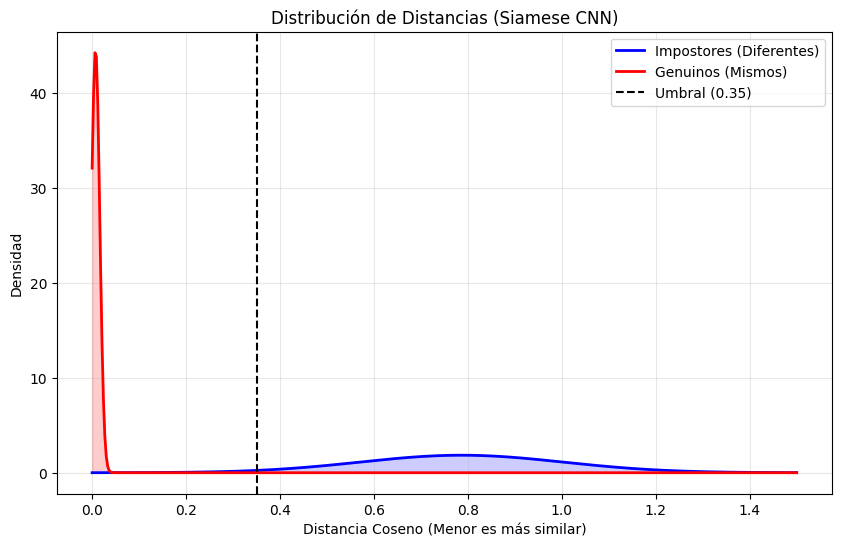

In [5]:
print("Generando gráficas de error...")
dibujar_curvas_error_ia(genuinos, impostores, umbral=0.35)

### Testing
Se ha implementado la función `procesar_y_comparar_test_ia` que se encarga de procesar las imágenes de test y compararlas con las huellas dactilares de la base de datos utilizando el modelo siamesa entrenado previamente.

#### Código de testing

In [6]:
procesar_y_comparar_test_ia(
    modelo=modelo,
    test_path=TEST_PATH,
    db_processed_path=OUT_PATH,
    umbral=0.15
)


FASE DE TEST: Identificando huellas desconocidas

Identificando: Huella_p1 copy 2.png
  >>> IDENTIFICADO: crd_0811f
      (Match con crd_0811f_01.png, Distancia: 0.0000)

Identificando: Huella_p1 copy 3.png
  >>> IDENTIFICADO: crd_0811f
      (Match con crd_0811f_01.png, Distancia: 0.0000)

Identificando: Huella_p1 copy 4.png
  >>> IDENTIFICADO: crd_0811f
      (Match con crd_0811f_01.png, Distancia: 0.0000)

Identificando: Huella_p1 copy 5.png
  >>> IDENTIFICADO: crd_0811f
      (Match con crd_0811f_01.png, Distancia: 0.0000)

Identificando: Huella_p1.png
  >>> IDENTIFICADO: crd_0811f
      (Match con crd_0811f_01.png, Distancia: 0.0000)

Identificando: Huella_p2.png
  >>> IDENTIFICADO: crd_0812f
      (Match con crd_0812f_01.png, Distancia: 0.0000)
